# Translation $T(t_x, t_y)$
Notebook to help with deriving closed-form geometric transforms and their gradients.

In [1]:
import sympy
from sympy import Matrix, Symbol

tx = Symbol("t_x")
ty = Symbol("t_y")

x = Symbol("x")
y = Symbol("y")
X = Matrix([x, y, 1])

### Transformation matrix

#### Composed (passive)
We assemble the passive transform `T_old_from_new` (which expresses the points in the old frame), which corresponds to the active transform `T_old_to_new`.

We then inverse this matrix to obtain the active transform `T_new_to_old`, which transforms a point in the translated image, to its original location in the untranslated image.

Translation component:

In [2]:
T_oldC_to_newC = Matrix([[1, 0, tx], [0, 1, ty], [0, 0, 1]])
T_oldC_to_newC

Matrix([
[1, 0, t_x],
[0, 1, t_y],
[0, 0,   1]])

In [3]:
T_oldC_from_newC = T_oldC_to_newC**-1
T_newC_from_oldC = sympy.simplify(T_oldC_from_newC)
T_newC_from_oldC

Matrix([
[1, 0, -t_x],
[0, 1, -t_y],
[0, 0,    1]])

In [4]:
T_newC_from_oldC @ X

Matrix([
[-t_x + x],
[-t_y + y],
[       1]])

Complete passive transform (Translation is shift-invariant, so no offset center is needed):

In [5]:
T_newO_from_oldO = T_newC_from_oldC
T_newO_from_oldO

Matrix([
[1, 0, -t_x],
[0, 1, -t_y],
[0, 0,    1]])

Move to active form:

In [6]:
T_newO_to_oldO = T_newO_from_oldO
T_newO_to_oldO

Matrix([
[1, 0, -t_x],
[0, 1, -t_y],
[0, 0,    1]])

Apply transformation to some pixel $(x,y)$:

In [7]:
X_new = Matrix([x, y, 1])
X_old_hom = T_newO_to_oldO @ X  # Homogeneous coordinates
X_old = Matrix([X_old_hom[0], X_old_hom[1]])
X_old

Matrix([
[-t_x + x],
[-t_y + y]])

### Gradient

In [8]:
grad_tx = sympy.Derivative(X_old, tx, evaluate=True)
grad_tx

Matrix([
[-1],
[ 0]])

In [9]:
grad_ty = sympy.Derivative(X_old, ty, evaluate=True)
grad_ty

Matrix([
[ 0],
[-1]])

Trying to understand the candidate locations for the maximum gradient:

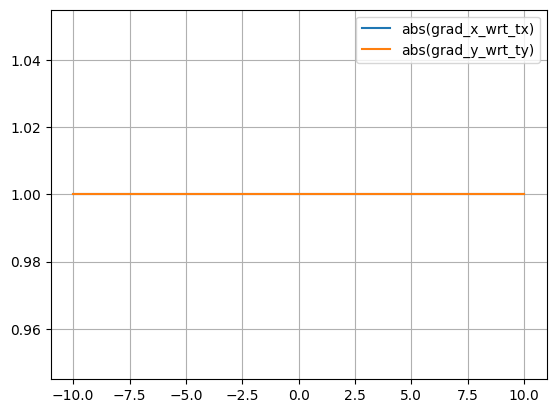

In [10]:
import matplotlib.pyplot as plt
import numpy as np

tx_vals = np.linspace(-10, 10, 100)
ty_vals = np.linspace(-10, 10, 100)

grad_x_wrt_tx = np.full_like(tx_vals, -1.0)
grad_y_wrt_ty = np.full_like(ty_vals, -1.0)

plt.figure()
plt.plot(tx_vals, np.abs(grad_x_wrt_tx), label="abs(grad_x_wrt_tx)")
plt.plot(ty_vals, np.abs(grad_y_wrt_ty), label="abs(grad_y_wrt_ty)")
plt.grid()
plt.legend()
plt.show()